# Model Fitness — Customer Churn Analysis

This project analyzes the profile of customers from a gym chain with the goal of predicting churn and developing data-driven retention strategies.

The dataset contains 4,000 records and 14 variables, including demographic, behavioral, and contractual customer data.

**The project is structured in five steps:**

- Step 1 — Data loading and inspection
- Step 2 — Exploratory Data Analysis (EDA)
- Step 3 — Predictive modeling (Logistic Regression and Random Forest)
- Step 4 — Customer clustering (K-Means)
- Step 5 — Conclusions and recommendations

## Step 1 — Data Loading

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.cluster.hierarchy import dendrogram, linkage
plt.style.use('dark_background')

df = pd.read_csv('data/gym_churn_us.csv')
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [2]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float64
 12  Avg

## Step 2 — Exploratory Data Analysis (EDA)

In this step, we investigate the structure and behavior of the dataset before any modeling.

**What was verified:**

- No missing values across all 14 variables
- General descriptive statistics using `describe()`
- Mean comparison between retained and churned customers using `groupby()`
- Visual distribution of variables by churn group (histograms)
- Relationships between variables (correlation matrix)

**Overall churn rate: 26%** — approximately 1 in 4 customers leaves the gym every month, which justifies the development of a data-driven retention strategy.

In [3]:
df.isna().sum()

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [4]:
df.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [5]:
churn_groups = df.groupby(df['Churn']).mean()

In [6]:
churn_groups

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


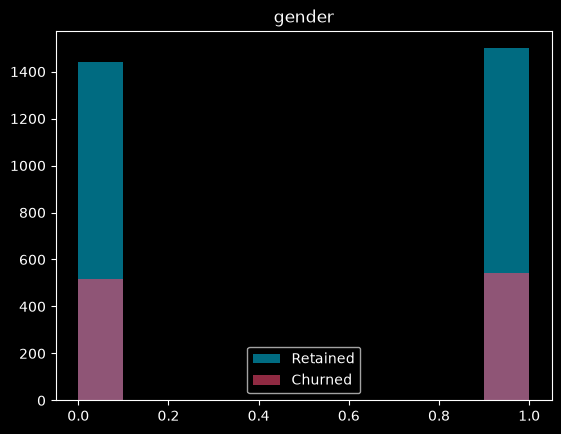

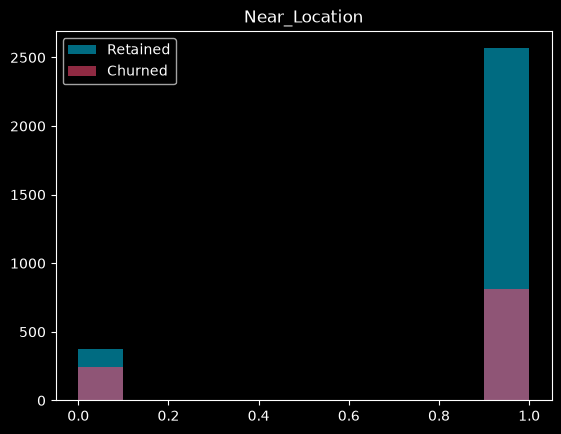

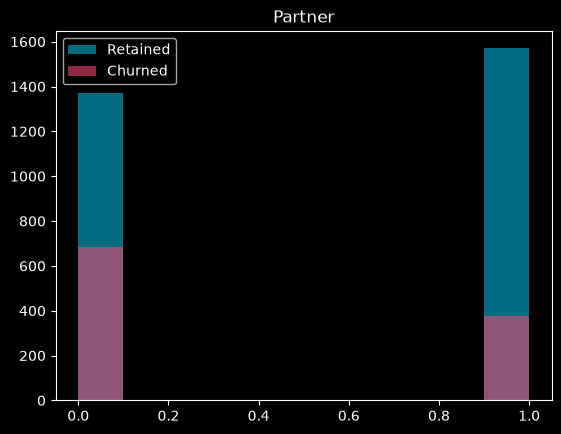

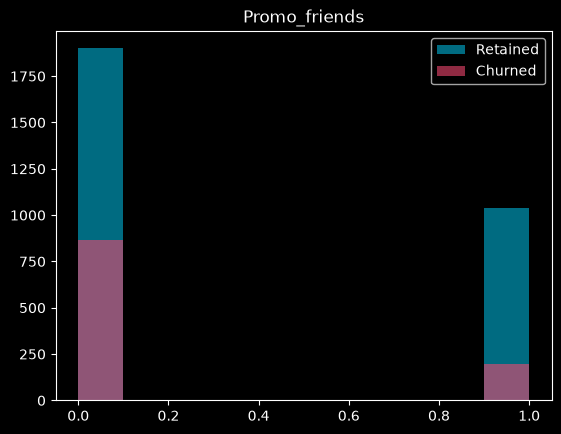

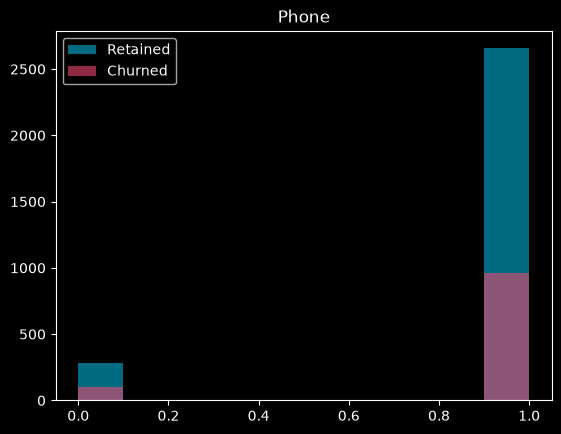

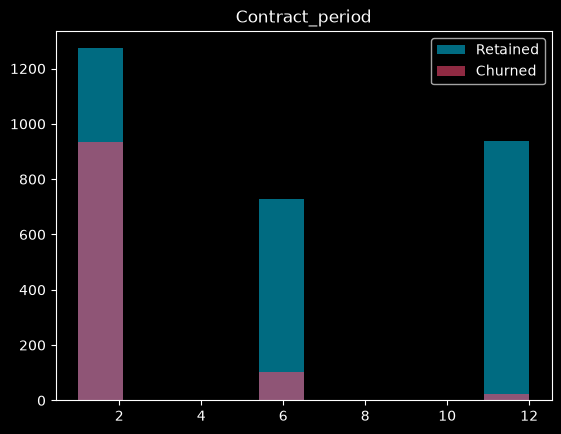

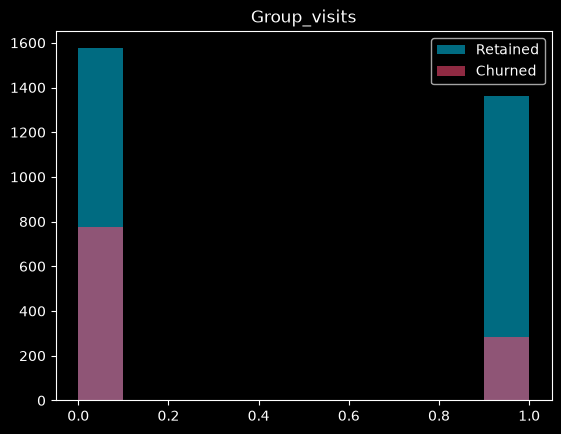

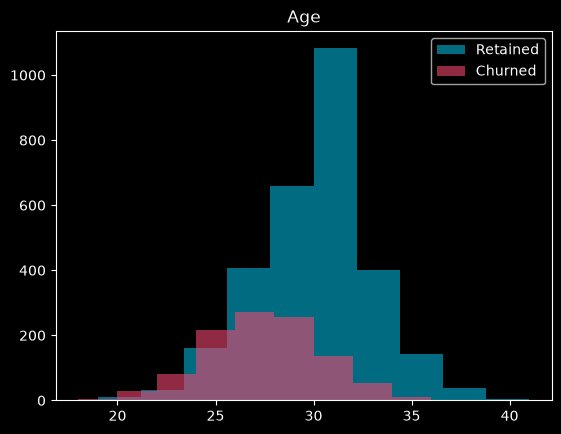

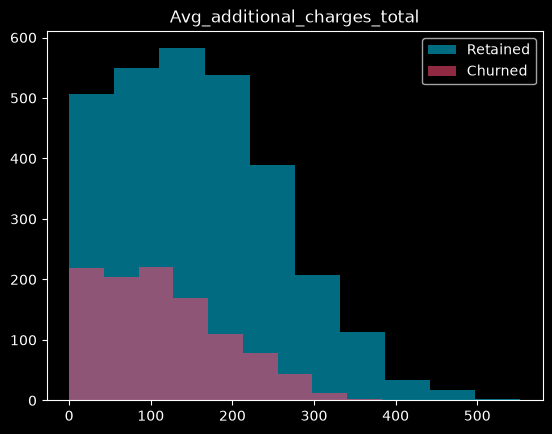

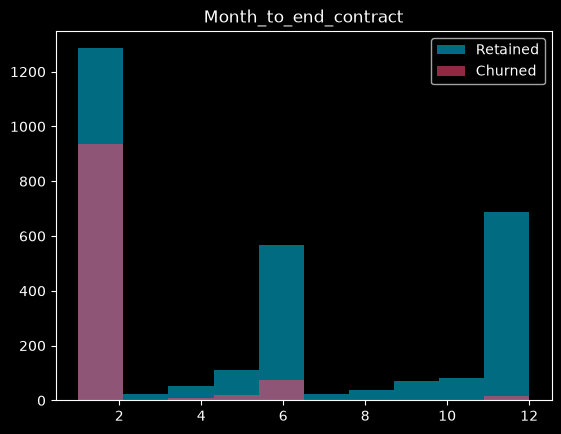

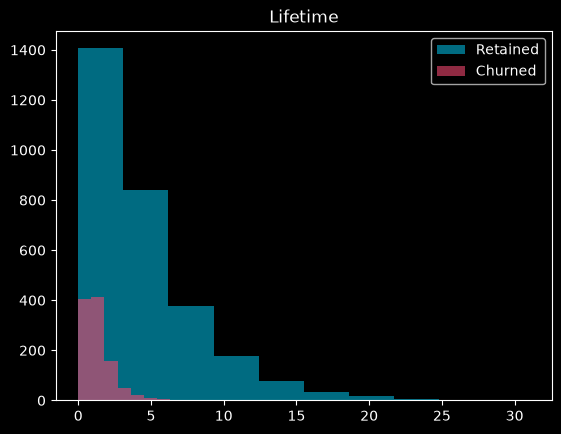

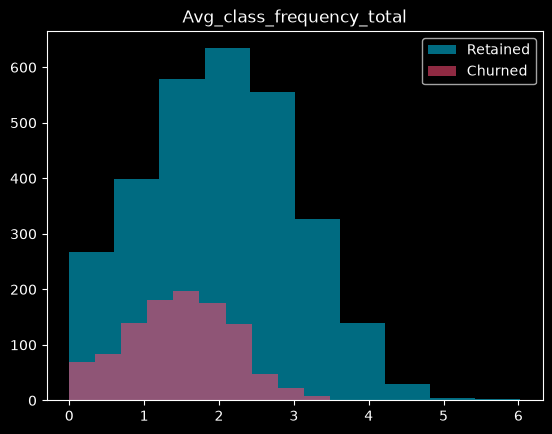

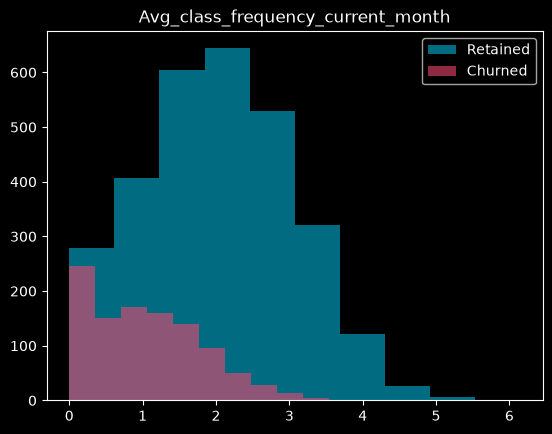

In [7]:
features = df.columns.drop('Churn')

for col in features:
    plt.hist(df[df['Churn'] == 0][col], alpha=0.6,
             label='Retained', color='#00B4D8')
    plt.hist(df[df['Churn'] == 1][col], alpha=0.6,
             label='Churned', color='#EF476F')
    plt.title(col)
    plt.legend()
    plt.show()

### Observations — Descriptive Statistics and Group Comparison

The average churn rate is **26%** — high for the sector, which justifies the analysis.

The group comparison revealed clear patterns:

- Customers with **longer contracts** show lower churn. Contractual commitment acts as a retention anchor
- The **less time remaining on a contract**, the higher the dropout risk — the customer does not renew and quietly leaves
- **New customers** (low Lifetime) churn more. Those who have been around longer have already built the habit
- **Current month frequency** is an immediate warning signal — those who visit less than twice a week tend to drop out
- Customers who participate in **group sessions** and who joined through **friend referrals** tend to be more loyal

<Axes: >

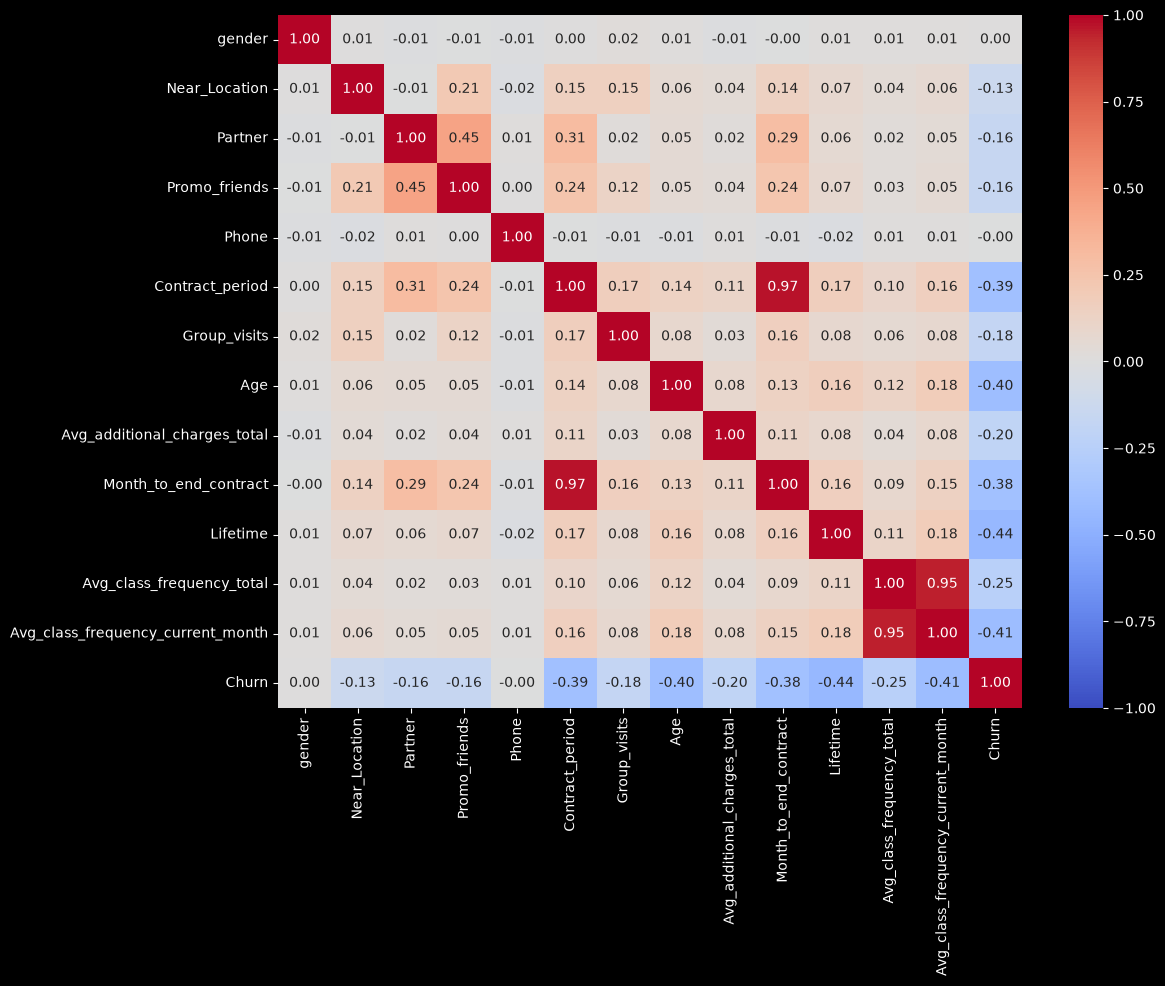

In [8]:
corr = df.corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

### Observations — Correlation Matrix

The matrix revealed two relevant patterns:

**Multicollinearity between variables:**
- `Contract_period` and `Month_to_end_contract` show a correlation of approx. 0.97 — they move almost in lockstep
- `Avg_class_frequency_total` and `Avg_class_frequency_current_month` show a correlation of approx. 0.95

This indicates redundant information between these pairs, which may impact the interpretation of coefficients in Logistic Regression.

**Correlation with Churn:**
- All correlations with `Churn` are negative — the higher the value of any relevant variable, the lower the dropout probability
- The variable with the greatest negative impact on churn is **Lifetime**: customers with less time at the gym are the most vulnerable to dropping out

## Step 3 — Predictive Modeling

Two binary classification models were trained to predict next-month churn, with an 80/20 train-test split (`random_state=88`).

| Metric | Logistic Regression | Random Forest |
|--------|-------------------|---------------|
| Accuracy | 0.9175 | 0.9138 |
| Precision | 0.8380 | 0.8488 |
| Recall | **0.8538** | 0.8208 |

**Chosen model: Logistic Regression**

In the context of customer retention, **recall** is the most relevant metric — we want to identify as many at-risk customers as possible, even if that generates some false alarms. The cost of reaching out to a customer who would have stayed anyway is far lower than the cost of ignoring someone who was about to leave.

Logistic Regression achieved superior recall (85.4% vs 82.1%), justifying its selection as the primary model.

In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=88)
model_lr = LogisticRegression(max_iter=4000)
model_lr = model_lr.fit(X_train, y_train)
trained_lr = model_lr.predict(X_test)
accuracy = accuracy_score(y_test, trained_lr)

In [11]:
print('Accuracy:', accuracy_score(y_test, trained_lr))
print('Precision:', precision_score(y_test, trained_lr))
print('Recall:', recall_score(y_test, trained_lr))

Accuracy: 0.9175
Precision: 0.8379629629629629
Recall: 0.8537735849056604


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=88)
model_rfc = RandomForestClassifier(random_state=88)
model_rfc = model_rfc.fit(X_train, y_train)
trained_rfc = model_rfc.predict(X_test)
accuracy = accuracy_score(y_test, trained_rfc)

In [13]:
print('Accuracy:', accuracy_score(y_test, trained_rfc))
print('Precision:', precision_score(y_test, trained_rfc))
print('Recall:', recall_score(y_test, trained_rfc))

Accuracy: 0.91375
Precision: 0.848780487804878
Recall: 0.8207547169811321


## Step 4 — Customer Clustering

The 4,000 customers were grouped into 5 clusters using K-Means (`n_clusters=5`, `random_state=88`), applied to data standardized by `StandardScaler`.

### Churn Rate by Cluster

| Cluster | Churn Rate | Profile |
|---------|-----------|---------|
| 0 | 2.8% | **Most loyal** |
| 1 | 26.8% | Average |
| 2 | **51.8%** | High risk |
| 3 | 44.4% | High risk |
| 4 | 6.8% | Loyal |

### Observations

- **Clusters 0 and 4** — customers with long contracts, high lifetime, and consistent visit frequency. Very low churn. These are the healthy core of the gym.

- **Cluster 2** — highest risk profile: very short lifetime (most below 6 months), contract about to expire, and lowest current visit frequency. A new customer who never built the habit and is about to leave silently.

- **Cluster 3** — also critical: contract nearly expired, low frequency. Differs from cluster 2 by having a slightly higher lifetime — a customer who was once engaged but has lost momentum.

- The analysis confirms the pattern identified in the EDA.

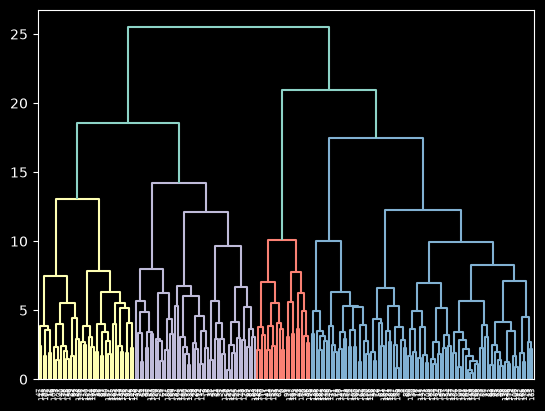

In [ ]:
scaler = StandardScaler()
df_std = scaler.fit_transform(X)
df_sample = df_std[:200]
linked = linkage(df_sample, method='ward')
dendrogram(linked)
plt.show()

In [15]:
kmeans = KMeans(n_clusters=5, random_state=88)
clusters = kmeans.fit_predict(df_std)

In [16]:
df['Cluster'] = clusters

In [17]:
cluster_mean = df.groupby('Cluster').mean()
print(cluster_mean)

           gender  Near_Location   Partner  Promo_friends     Phone  \
Cluster                                                               
0        0.507307       0.946764  0.742171       0.517745  0.900835   
1        0.479716       1.000000  0.000000       0.091278  0.908722   
2        0.491781       1.000000  0.986301       0.579452  0.894521   
3        0.580231       0.973042  0.335045       0.234917  0.899872   
4        0.495430       0.000000  0.466179       0.076782  0.915905   

         Contract_period  Group_visits        Age  \
Cluster                                             
0              11.736952      0.561587  29.943633   
1               1.846856      0.358012  28.289047   
2               2.915068      0.367123  28.668493   
3               2.958922      0.478819  30.356868   
4               2.243144      0.213894  28.486289   

         Avg_additional_charges_total  Month_to_end_contract  Lifetime  \
Cluster                                                 

In [18]:
churn_mean = df.groupby('Cluster')['Churn'].mean()
churn_mean

Cluster
0    0.020877
1    0.520284
2    0.354795
3    0.030809
4    0.447898
Name: Churn, dtype: float64

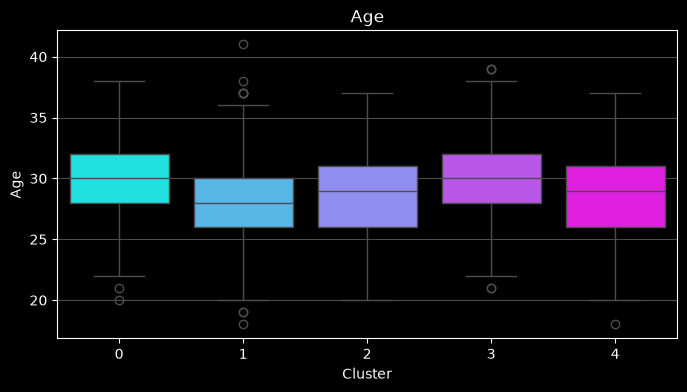

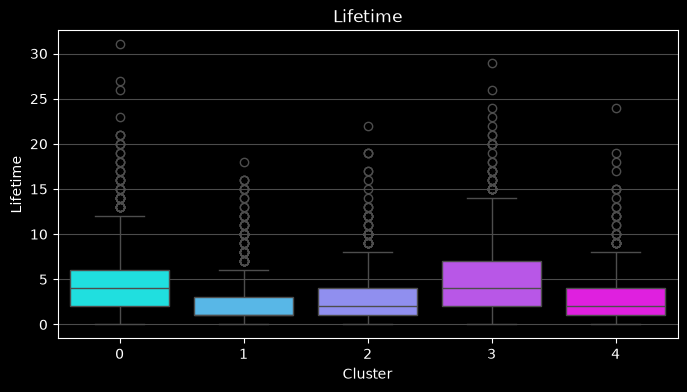

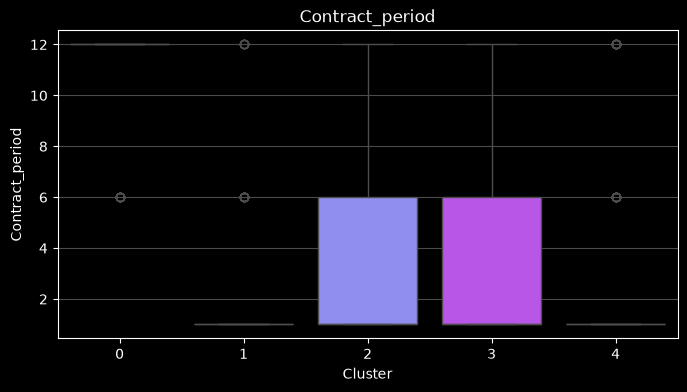

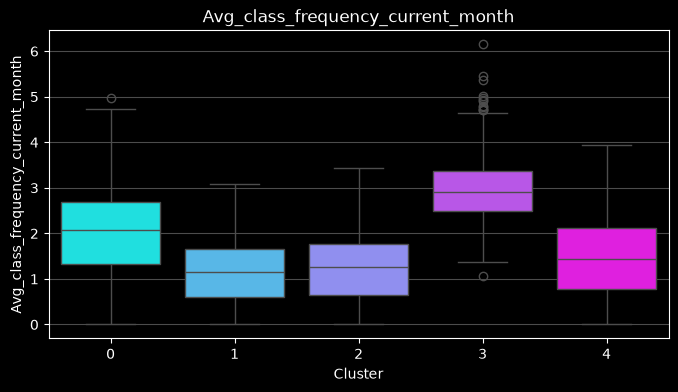

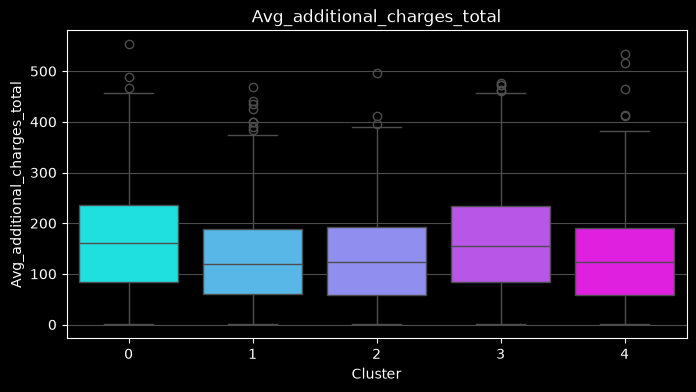

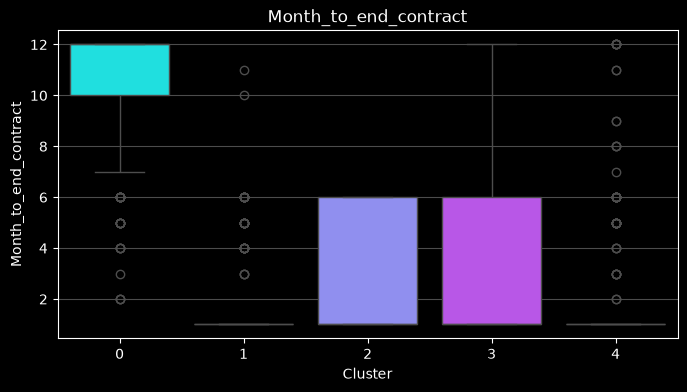

In [19]:
key_features = ['Age', 'Lifetime', 'Contract_period',
                'Avg_class_frequency_current_month',
                'Avg_additional_charges_total',
                'Month_to_end_contract']

for col in key_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Cluster', y=col, hue='Cluster',
                palette='cool', legend=False)
    plt.title(col)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Step 5 — Conclusions and Recommendations

### Conclusions

Retention at Model Fitness is driven by three main factors, identified in both the EDA and clustering:

- **Contract duration** — long contracts create commitment and reduce churn
- **Customer tenure (Lifetime)** — long-term customers have built the habit; new ones are the most vulnerable
- **Current visit frequency** — a drop in frequency is the most immediate warning signal

Logistic Regression predicted churn with **Accuracy of 91.7%** and **Recall of 85.3%**, and was selected as the primary model for minimizing false negatives — at-risk customers who would otherwise go undetected.

Clusters 2 and 3 concentrate the highest-risk customers: contracts about to expire, low lifetime, and declining visit frequency.

**Technical note:** The variables `Contract_period` and `Month_to_end_contract` (approx. 0.97) and `Avg_class_frequency_total` and `current_month` (approx. 0.95) show high multicollinearity. In future projects, consolidating these pairs would reduce model redundancy.

### Recommendations

**1. Encourage early renewal and long-term contracts**
Offer progressive discounts for longer contracts and early renewals. Quality gifts (gym towel, supplement shaker) can reinforce the bond at renewal time. Focus on clusters 2 and 3, where contracts are about to expire.

**2. Loyalty program based on tenure**
The longer a member stays, the greater their accumulated discount — similar to no-claim bonuses in insurance. Additional bonuses for uninterrupted attendance reinforce the habit in the critical early months.

**3. Promote group classes**
Discounts for plans that include group sessions reduce churn (group participants are more loyal) and optimize fixed instructor costs. Informational content showcasing results from veteran members can engage younger audiences without relying solely on discounts.

**4. Referral program**
Discounts for members who bring a friend, partner, or colleague. Customers who joined via referral (`Promo_friends`) already show higher retention rates in the data — expanding this channel is low-cost and high-impact.